In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, ttest_ind, chi2_contingency, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


In [6]:
np.random.seed(42)

n_control = 5000 
n_treatment = 5000 

true_rate_control = 0.12 
true_rate_treatment = 0.135  

control_conversions = np.random.binomial(1, true_rate_control, n_control)
treatment_conversions = np.random.binomial(1, true_rate_treatment, n_treatment)

df_ab = pd.DataFrame({
    'group': ['control'] * n_control + ['treatment'] * n_treatment,
    'converted': np.concatenate([control_conversions, treatment_conversions])
})

print("A/B Test Data Summary:")
print(f"  Control group:   {n_control} visitors")
print(f"  Treatment group: {n_treatment} visitors")
print(f"\nConversion rates:")
print(df_ab.groupby('group')['converted'].agg(['sum', 'count', 'mean']).round(4))

A/B Test Data Summary:
  Control group:   5000 visitors
  Treatment group: 5000 visitors

Conversion rates:
           sum  count    mean
group                        
control    578   5000  0.1156
treatment  638   5000  0.1276


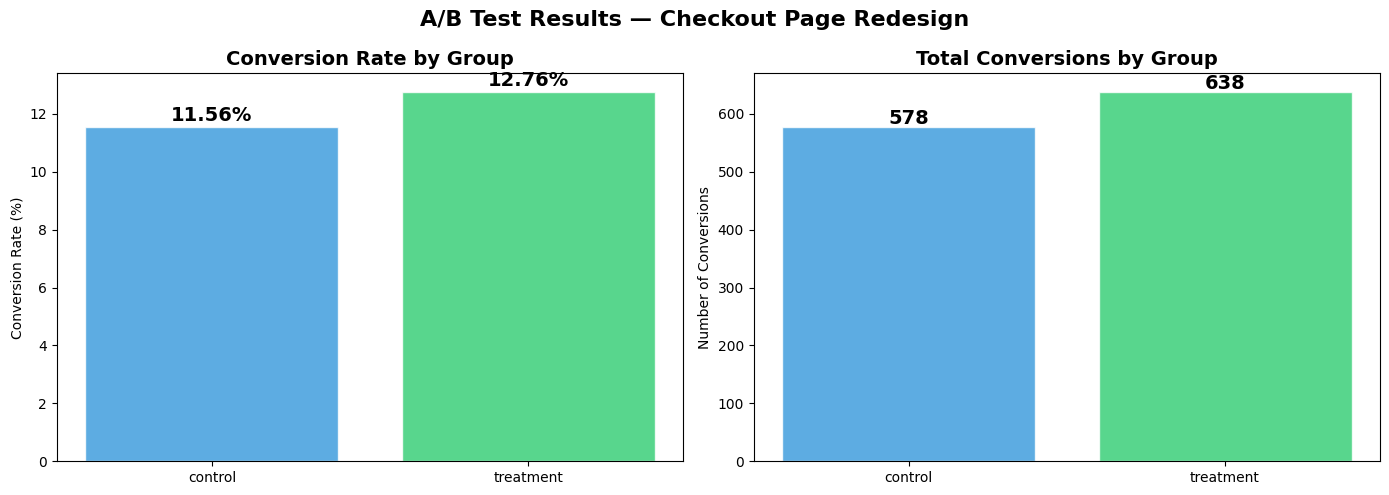

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rates = df_ab.groupby('group')['converted'].mean()
colors = ['#3498db', '#2ecc71']
axes[0].bar(rates.index, rates.values * 100, color=colors, alpha=0.8, edgecolor='white')
axes[0].set_title('Conversion Rate by Group', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Conversion Rate (%)')
for i, (group, rate) in enumerate(rates.items()):
    axes[0].text(i, rate * 100 + 0.2, f'{rate:.2%}', ha='center', fontsize=14, fontweight='bold')


counts = df_ab.groupby('group')['converted'].sum()
axes[1].bar(counts.index, counts.values, color=colors, alpha=0.8, edgecolor='white')
axes[1].set_title('Total Conversions by Group', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Conversions')
for i, (group, count) in enumerate(counts.items()):
    axes[1].text(i, count + 5, str(int(count)), ha='center', fontsize=14, fontweight='bold')

plt.suptitle('A/B Test Results — Checkout Page Redesign', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('01_ab_conversion_rates.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
rate_control = df_ab[df_ab['group'] == 'control']['converted'].mean()
rate_treatment = df_ab[df_ab['group'] == 'treatment']['converted'].mean()
lift = (rate_treatment - rate_control) / rate_control * 100

print(f"\nControl conversion rate:   {rate_control:.4f} ({rate_control:.2%})")
print(f"Treatment conversion rate: {rate_treatment:.4f} ({rate_treatment:.2%})")
print(f"Absolute difference:       {rate_treatment - rate_control:.4f}")
print(f"Relative lift:             {lift:.1f}%")

print(f"""
THE QUESTION:
Treatment has a higher conversion rate than Control.
But is this difference REAL or just random noise?

If we ran the same test again, would we see the same result?
Or did we just get lucky with this particular batch of visitors?

THIS is what hypothesis testing answers.
""")


Control conversion rate:   0.1156 (11.56%)
Treatment conversion rate: 0.1276 (12.76%)
Absolute difference:       0.0120
Relative lift:             10.4%

THE QUESTION:
Treatment has a higher conversion rate than Control.
But is this difference REAL or just random noise?

If we ran the same test again, would we see the same result?
Or did we just get lucky with this particular batch of visitors?

THIS is what hypothesis testing answers.



In [10]:
print("=" * 60)
print("HYPOTHESIS TESTING FRAMEWORK")
print("=" * 60)
print("""
NULL HYPOTHESIS (H₀):
  "There is NO difference between control and treatment."
  "The new checkout page does NOT improve conversion."
  "Any observed difference is due to random chance."
  
  Mathematically: p_treatment = p_control
  (or equivalently: p_treatment - p_control = 0)

ALTERNATIVE HYPOTHESIS (H₁):
  "There IS a difference between control and treatment."
  "The new checkout page DOES change conversion."
  
  Mathematically: p_treatment ≠ p_control

THE LOGIC:
  1. ASSUME H₀ is true (no difference exists)
  2. Calculate: how likely is our observed data IF H₀ were true?
  3. If very unlikely (p-value < 0.05): reject H₀ → difference is REAL
  4. If not unlikely (p-value >= 0.05): fail to reject H₀ → can't prove difference

ANALOGY:
  Court trial. H₀ = "defendant is innocent."
  Evidence = data from the experiment.
  If evidence is overwhelming (p < 0.05) → guilty (reject H₀).
  If evidence is weak (p >= 0.05) → not guilty (fail to reject H₀).
  Note: "not guilty" ≠ "innocent". Just "not enough evidence."
""")

HYPOTHESIS TESTING FRAMEWORK

NULL HYPOTHESIS (H₀):
  "There is NO difference between control and treatment."
  "The new checkout page does NOT improve conversion."
  "Any observed difference is due to random chance."

  Mathematically: p_treatment = p_control
  (or equivalently: p_treatment - p_control = 0)

ALTERNATIVE HYPOTHESIS (H₁):
  "There IS a difference between control and treatment."
  "The new checkout page DOES change conversion."

  Mathematically: p_treatment ≠ p_control

THE LOGIC:
  1. ASSUME H₀ is true (no difference exists)
  2. Calculate: how likely is our observed data IF H₀ were true?
  3. If very unlikely (p-value < 0.05): reject H₀ → difference is REAL
  4. If not unlikely (p-value >= 0.05): fail to reject H₀ → can't prove difference

ANALOGY:
  Court trial. H₀ = "defendant is innocent."
  Evidence = data from the experiment.
  If evidence is overwhelming (p < 0.05) → guilty (reject H₀).
  If evidence is weak (p >= 0.05) → not guilty (fail to reject H₀).
  Note: 

In [11]:
p_control = control_conversions.sum() / n_control
p_treatment = treatment_conversions.sum() / n_treatment
p_pooled = (control_conversions.sum() + treatment_conversions.sum()) / (n_control + n_treatment)

se = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_control + 1/n_treatment))

z_stat = (p_treatment - p_control) / se

p_value = 2 * (1 - norm.cdf(abs(z_stat)))

print("=" * 60)
print("Z-TEST FOR PROPORTIONS")
print("=" * 60)
print(f"""
  Control conversion rate:    {p_control:.4f}
  Treatment conversion rate:  {p_treatment:.4f}
  Pooled proportion:          {p_pooled:.4f}
  Standard Error:             {se:.4f}
  
  Z-statistic:                {z_stat:.4f}
  P-value:                    {p_value:.4f}
  
  Significance level (α):     0.05
""")

if p_value < 0.05:
    print("  RESULT: ✅ REJECT H₀ — The difference IS statistically significant!")
    print("  The new checkout page significantly changes conversion rate.")
else:
    print("  RESULT: ❌ FAIL TO REJECT H₀ — The difference is NOT significant.")
    print("  We cannot conclude the new page improves conversion.")

Z-TEST FOR PROPORTIONS

  Control conversion rate:    0.1156
  Treatment conversion rate:  0.1276
  Pooled proportion:          0.1216
  Standard Error:             0.0065

  Z-statistic:                1.8359
  P-value:                    0.0664

  Significance level (α):     0.05

  RESULT: ❌ FAIL TO REJECT H₀ — The difference is NOT significant.
  We cannot conclude the new page improves conversion.


In [12]:
se_diff = np.sqrt(
    p_control * (1 - p_control) / n_control +
    p_treatment * (1 - p_treatment) / n_treatment
)

diff = p_treatment - p_control
ci_lower = diff - 1.96 * se_diff
ci_upper = diff + 1.96 * se_diff

print(f"\n95% Confidence Interval for the difference:")
print(f"  Difference: {diff:.4f}")
print(f"  CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"  CI: [{ci_lower:.2%}, {ci_upper:.2%}]")

if ci_lower > 0:
    print(f"\n  Since the CI does NOT include 0, the treatment is significantly better.")
elif ci_upper < 0:
    print(f"\n  Since the CI is entirely negative, the treatment is significantly worse.")
else:
    print(f"\n  Since the CI INCLUDES 0, we can't be sure of a real difference.")


95% Confidence Interval for the difference:
  Difference: 0.0120
  CI: [-0.0008, 0.0248]
  CI: [-0.08%, 2.48%]

  Since the CI INCLUDES 0, we can't be sure of a real difference.


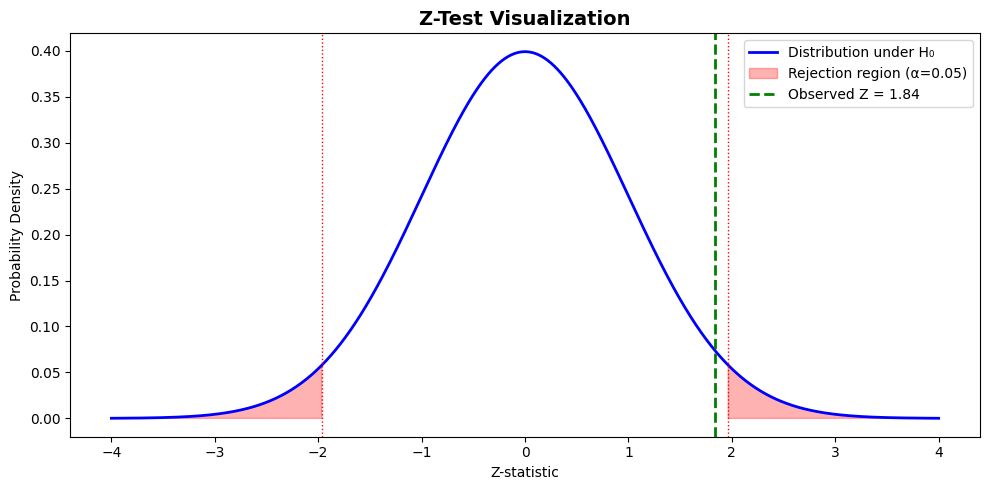

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)
ax.plot(x, y, 'b-', linewidth=2, label='Distribution under H₀')
ax.fill_between(x, y, where=(x < -1.96) | (x > 1.96), alpha=0.3, color='red',
                label='Rejection region (α=0.05)')
ax.axvline(z_stat, color='green', linewidth=2, linestyle='--',
           label=f'Observed Z = {z_stat:.2f}')
ax.axvline(-1.96, color='red', linewidth=1, linestyle=':')
ax.axvline(1.96, color='red', linewidth=1, linestyle=':')
ax.set_title('Z-Test Visualization', fontsize=14, fontweight='bold')
ax.set_xlabel('Z-statistic')
ax.set_ylabel('Probability Density')
ax.legend()
plt.tight_layout()
plt.savefig('02_z_test_visualization.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
np.random.seed(123)

control_aov = np.random.normal(loc=75, scale=25, size=500)   
treatment_aov = np.random.normal(loc=82, scale=28, size=500)

control_aov = control_aov[control_aov > 0]
treatment_aov = treatment_aov[treatment_aov > 0]

print(f"Control group:   n={len(control_aov)}, mean=${control_aov.mean():.2f}, std=${control_aov.std():.2f}")
print(f"Treatment group: n={len(treatment_aov)}, mean=${treatment_aov.mean():.2f}, std=${treatment_aov.std():.2f}")
print(f"Difference:      ${treatment_aov.mean() - control_aov.mean():.2f}")


Control group:   n=499, mean=$74.19, std=$24.85
Treatment group: n=499, mean=$81.04, std=$27.71
Difference:      $6.85


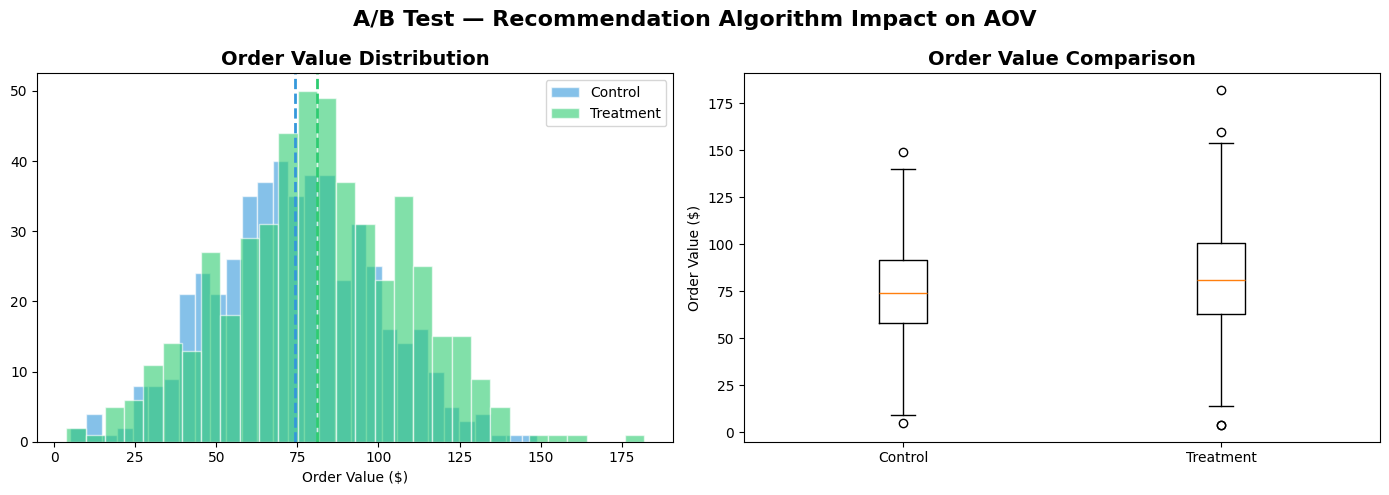

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(control_aov, bins=30, alpha=0.6, color='#3498db', label='Control', edgecolor='white')
axes[0].hist(treatment_aov, bins=30, alpha=0.6, color='#2ecc71', label='Treatment', edgecolor='white')
axes[0].axvline(control_aov.mean(), color='#3498db', linewidth=2, linestyle='--')
axes[0].axvline(treatment_aov.mean(), color='#2ecc71', linewidth=2, linestyle='--')
axes[0].set_title('Order Value Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Order Value ($)')
axes[0].legend()

# Box plot
axes[1].boxplot([control_aov, treatment_aov], labels=['Control', 'Treatment'])
axes[1].set_title('Order Value Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Order Value ($)')

plt.suptitle('A/B Test — Recommendation Algorithm Impact on AOV', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('03_ttest_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
t_stat, t_pvalue = ttest_ind(treatment_aov, control_aov)

print(f"\n{'=' * 60}")
print("INDEPENDENT SAMPLES T-TEST")
print(f"{'=' * 60}")
print(f"  T-statistic: {t_stat:.4f}")
print(f"  P-value:     {t_pvalue:.4f}")

if t_pvalue < 0.05:
    print(f"\n  ✅ SIGNIFICANT: The new algorithm increases average order value.")
else:
    print(f"\n  ❌ NOT SIGNIFICANT: Cannot confirm the new algorithm improves AOV.")


INDEPENDENT SAMPLES T-TEST
  T-statistic: 4.1062
  P-value:     0.0000

  ✅ SIGNIFICANT: The new algorithm increases average order value.


In [17]:
pooled_std = np.sqrt((control_aov.std()**2 + treatment_aov.std()**2) / 2)
cohens_d = (treatment_aov.mean() - control_aov.mean()) / pooled_std

print(f"\nEffect Size (Cohen's d): {cohens_d:.3f}")
print(f"""
  Cohen's d interpretation:
    < 0.2  = Small effect
    0.2-0.5 = Small-Medium effect
    0.5-0.8 = Medium-Large effect
    > 0.8  = Large effect
  
  Our d = {cohens_d:.3f} → {'Small' if abs(cohens_d) < 0.2 else 'Small-Medium' if abs(cohens_d) < 0.5 else 'Medium-Large' if abs(cohens_d) < 0.8 else 'Large'} effect

WHY EFFECT SIZE MATTERS:
  P-value tells you: IS there a difference? (yes/no)
  Effect size tells you: HOW BIG is the difference?
  
  With 1 million users, even a $0.01 difference becomes "significant" (p < 0.05).
  But a $0.01 increase isn't worth implementing a new algorithm.
  
  STATISTICAL significance ≠ PRACTICAL significance.
  Always report both p-value AND effect size.
""")


Effect Size (Cohen's d): 0.260

  Cohen's d interpretation:
    < 0.2  = Small effect
    0.2-0.5 = Small-Medium effect
    0.5-0.8 = Medium-Large effect
    > 0.8  = Large effect

  Our d = 0.260 → Small-Medium effect

WHY EFFECT SIZE MATTERS:
  P-value tells you: IS there a difference? (yes/no)
  Effect size tells you: HOW BIG is the difference?

  With 1 million users, even a $0.01 difference becomes "significant" (p < 0.05).
  But a $0.01 increase isn't worth implementing a new algorithm.

  STATISTICAL significance ≠ PRACTICAL significance.
  Always report both p-value AND effect size.



In [18]:
np.random.seed(99)

colors_data = {
    'Red':   {'Buy': 120, 'Browse': 380},
    'Blue':  {'Buy': 150, 'Browse': 350},
    'Green': {'Buy': 165, 'Browse': 335},
}


contingency = pd.DataFrame(colors_data).T
contingency.columns = ['Buy', 'Browse']
contingency['Total'] = contingency.sum(axis=1)
contingency['Buy_Rate'] = contingency['Buy'] / contingency['Total']

print("Contingency Table:")
print(contingency)
print(f"\nBuy rates: Red={120/500:.1%}, Blue={150/500:.1%}, Green={165/500:.1%}")


Contingency Table:
       Buy  Browse  Total  Buy_Rate
Red    120     380    500      0.24
Blue   150     350    500      0.30
Green  165     335    500      0.33

Buy rates: Red=24.0%, Blue=30.0%, Green=33.0%


In [19]:
observed = np.array([[120, 380], [150, 350], [165, 335]])

chi2, chi2_pvalue, dof, expected = chi2_contingency(observed)

print(f"\n{'=' * 60}")
print("CHI-SQUARE TEST OF INDEPENDENCE")
print(f"{'=' * 60}")
print(f"  Chi² statistic:    {chi2:.4f}")
print(f"  Degrees of freedom: {dof}")
print(f"  P-value:           {chi2_pvalue:.4f}")
print(f"\n  Expected frequencies (if no relationship):")
print(pd.DataFrame(expected.round(1),
                   index=['Red', 'Blue', 'Green'],
                   columns=['Buy', 'Browse']))

if chi2_pvalue < 0.05:
    print(f"\n  ✅ SIGNIFICANT: Button color IS associated with purchase behavior.")
else:
    print(f"\n  ❌ NOT SIGNIFICANT: No evidence that color affects purchases.")


CHI-SQUARE TEST OF INDEPENDENCE
  Chi² statistic:    10.1991
  Degrees of freedom: 2
  P-value:           0.0061

  Expected frequencies (if no relationship):
         Buy  Browse
Red    145.0   355.0
Blue   145.0   355.0
Green  145.0   355.0

  ✅ SIGNIFICANT: Button color IS associated with purchase behavior.


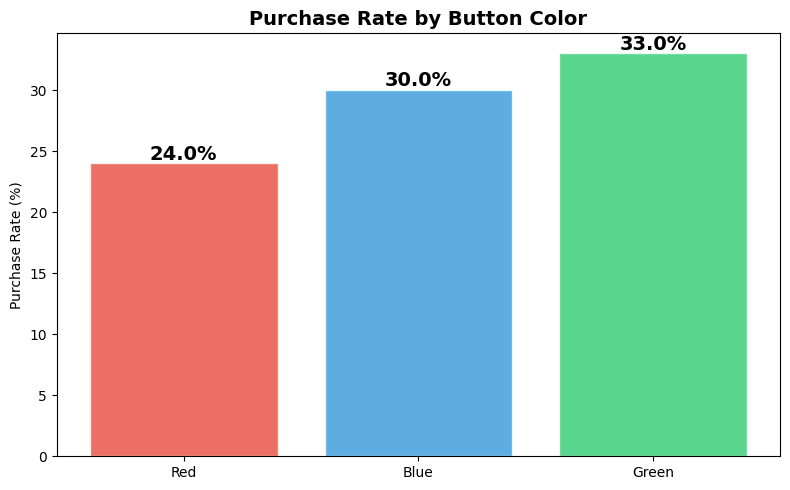

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
buy_rates = [120/500*100, 150/500*100, 165/500*100]
bars = ax.bar(['Red', 'Blue', 'Green'], buy_rates,
              color=['#e74c3c', '#3498db', '#2ecc71'], alpha=0.8, edgecolor='white')
for bar, rate in zip(bars, buy_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{rate:.1f}%', ha='center', fontsize=14, fontweight='bold')
ax.set_title('Purchase Rate by Button Color', fontsize=14, fontweight='bold')
ax.set_ylabel('Purchase Rate (%)')
plt.tight_layout()
plt.savefig('04_chi_square_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
print("""
STATISTICAL POWER
=================

Type I Error (α = 0.05):
  False Positive. Conclude there's a difference when there ISN'T one.
  "The new page is better!" but actually it's the same. 
  Controlled by significance level (α = 0.05 means 5% chance).

Type II Error (β):
  False Negative. Conclude there's NO difference when there IS one.
  "The new page is the same" but actually it's better.
  You MISSED a real improvement!

Power = 1 - β:
  Probability of detecting a REAL difference when one exists.
  Power = 0.80 means: if the difference is real, we'll detect it 80% of the time.
  Industry standard: aim for power ≥ 0.80.

THE FOUR CONNECTED VARIABLES:
  1. Sample size (n):     MORE data → MORE power
  2. Effect size (d):     BIGGER difference → MORE power → LESS data needed
  3. Significance (α):    Stricter threshold → LESS power
  4. Power (1-β):         Target = 0.80

  Know ANY THREE → calculate the FOURTH.
  Most common: know effect size, α, power → calculate REQUIRED sample size.
""")


STATISTICAL POWER

Type I Error (α = 0.05):
  False Positive. Conclude there's a difference when there ISN'T one.
  "The new page is better!" but actually it's the same. 
  Controlled by significance level (α = 0.05 means 5% chance).

Type II Error (β):
  False Negative. Conclude there's NO difference when there IS one.
  "The new page is the same" but actually it's better.
  You MISSED a real improvement!

Power = 1 - β:
  Probability of detecting a REAL difference when one exists.
  Power = 0.80 means: if the difference is real, we'll detect it 80% of the time.
  Industry standard: aim for power ≥ 0.80.

THE FOUR CONNECTED VARIABLES:
  1. Sample size (n):     MORE data → MORE power
  2. Effect size (d):     BIGGER difference → MORE power → LESS data needed
  3. Significance (α):    Stricter threshold → LESS power
  4. Power (1-β):         Target = 0.80

  Know ANY THREE → calculate the FOURTH.
  Most common: know effect size, α, power → calculate REQUIRED sample size.



In [22]:
def required_sample_size(baseline_rate, min_detectable_effect, alpha=0.05, power=0.80):
    """
    Calculate required sample size per group for an A/B test on proportions.
    
    baseline_rate: current conversion rate (e.g., 0.12 for 12%)
    min_detectable_effect: minimum relative improvement to detect (e.g., 0.10 for 10%)
    """
    p1 = baseline_rate
    p2 = baseline_rate * (1 + min_detectable_effect)
    
    # Z-values
    z_alpha = norm.ppf(1 - alpha/2)  # 1.96 for α=0.05
    z_beta = norm.ppf(power)          # 0.84 for power=0.80
    
    # Pooled proportion
    p_bar = (p1 + p2) / 2
    
    # Sample size formula
    n = ((z_alpha * np.sqrt(2 * p_bar * (1-p_bar)) + 
          z_beta * np.sqrt(p1*(1-p1) + p2*(1-p2)))**2) / (p2-p1)**2
    
    return int(np.ceil(n))

# Calculate for different scenarios
print("REQUIRED SAMPLE SIZE PER GROUP:")
print("-" * 65)
print(f"{'Baseline':>10} {'Min Effect':>12} {'New Rate':>10} {'N per Group':>12} {'Total N':>10}")
print("-" * 65)

for baseline in [0.05, 0.10, 0.12, 0.20]:
    for effect in [0.05, 0.10, 0.20]:
        n = required_sample_size(baseline, effect)
        new_rate = baseline * (1 + effect)
        print(f"{baseline:>10.1%} {effect:>12.0%} {new_rate:>10.1%} {n:>12,} {2*n:>10,}")
    print()

print("""
KEY INSIGHTS:
  1. Smaller effects need MUCH MORE data to detect
     (10% lift needs ~4x the data of 20% lift)
  
  2. Lower baseline rates need MORE data
     (detecting change from 5% to 5.5% is harder than 20% to 22%)
  
  3. This is why you calculate sample size BEFORE running the test!
     Running a test with too few users = wasting time (you'll never reach significance)
""")

REQUIRED SAMPLE SIZE PER GROUP:
-----------------------------------------------------------------
  Baseline   Min Effect   New Rate  N per Group    Total N
-----------------------------------------------------------------
      5.0%           5%       5.3%      122,124    244,248
      5.0%          10%       5.5%       31,234     62,468
      5.0%          20%       6.0%        8,158     16,316

     10.0%           5%      10.5%       57,763    115,526
     10.0%          10%      11.0%       14,751     29,502
     10.0%          20%      12.0%        3,841      7,682

     12.0%           5%      12.6%       47,036     94,072
     12.0%          10%      13.2%       12,004     24,008
     12.0%          20%      14.4%        3,122      6,244

     20.0%           5%      21.0%       25,583     51,166
     20.0%          10%      22.0%        6,510     13,020
     20.0%          20%      24.0%        1,683      3,366


KEY INSIGHTS:
  1. Smaller effects need MUCH MORE data to detect

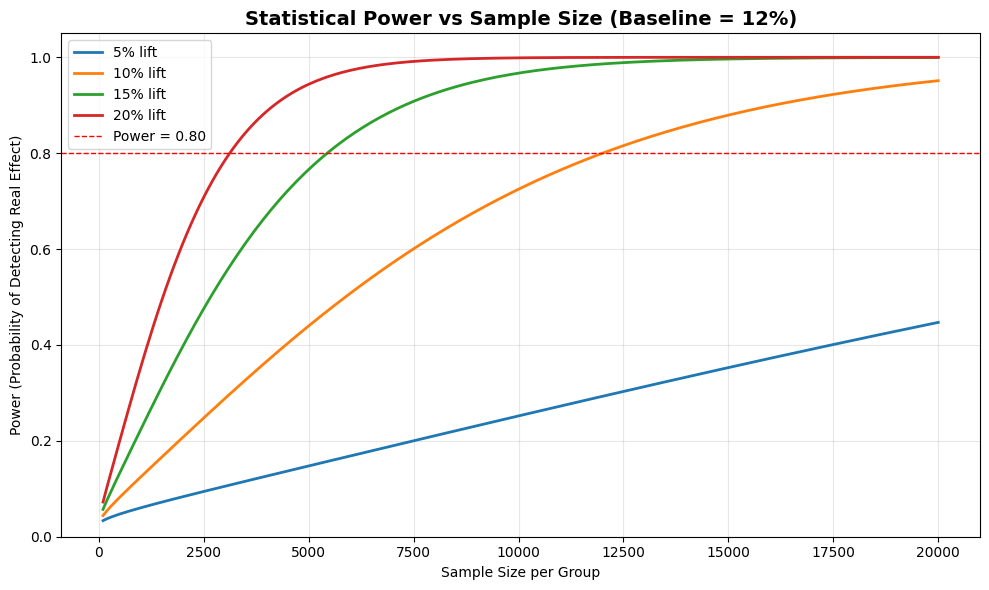

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

sample_sizes = range(100, 20001, 100)
baseline = 0.12

for mde in [0.05, 0.10, 0.15, 0.20]:
    powers = []
    p2 = baseline * (1 + mde)
    for n in sample_sizes:
        se = np.sqrt(baseline*(1-baseline)/n + p2*(1-p2)/n)
        z_crit = 1.96
        z_power = (abs(p2 - baseline) / se) - z_crit
        power = norm.cdf(z_power)
        powers.append(power)
    ax.plot(sample_sizes, powers, linewidth=2, label=f'{mde:.0%} lift')

ax.axhline(0.80, color='red', linewidth=1, linestyle='--', label='Power = 0.80')
ax.set_title('Statistical Power vs Sample Size (Baseline = 12%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample Size per Group')
ax.set_ylabel('Power (Probability of Detecting Real Effect)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('05_power_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
print("""
MULTIPLE TESTING PROBLEM
========================

If you run 1 test at α=0.05:
  5% chance of a false positive. Fine.

If you run 20 tests at α=0.05:
  P(at least one false positive) = 1 - (1-0.05)²⁰ = 64%!
  You'll almost certainly find a "significant" result by chance!

This happens when you test:
  - Multiple metrics (conversion, revenue, clicks, time on page)
  - Multiple segments (mobile vs desktop, US vs UK, new vs returning)
  - Multiple variants (A vs B vs C vs D)

SOLUTION: Bonferroni Correction
  Adjusted α = 0.05 / number_of_tests
  
  Running 5 tests? Use α = 0.05/5 = 0.01 per test.
  Running 10 tests? Use α = 0.05/10 = 0.005 per test.
  
  More conservative but prevents false discoveries.
""")

# Example: testing 5 metrics
n_tests = 5
alpha_original = 0.05
alpha_bonferroni = alpha_original / n_tests

# Simulated p-values from 5 different metrics
simulated_pvalues = [0.03, 0.12, 0.008, 0.45, 0.04]
metric_names = ['Conversion Rate', 'Avg Order Value', 'Click-Through Rate', 
                'Bounce Rate', 'Pages per Session']

print(f"\nBonferroni Correction (α = {alpha_original} / {n_tests} = {alpha_bonferroni})")
print("-" * 70)
print(f"{'Metric':<25} {'P-value':>10} {'Original':>12} {'Bonferroni':>12}")
print("-" * 70)
for name, pval in zip(metric_names, simulated_pvalues):
    orig = "✅ Sig" if pval < alpha_original else "❌ Not Sig"
    bonf = "✅ Sig" if pval < alpha_bonferroni else "❌ Not Sig"
    print(f"{name:<25} {pval:>10.3f} {orig:>12} {bonf:>12}")


MULTIPLE TESTING PROBLEM

If you run 1 test at α=0.05:
  5% chance of a false positive. Fine.

If you run 20 tests at α=0.05:
  P(at least one false positive) = 1 - (1-0.05)²⁰ = 64%!
  You'll almost certainly find a "significant" result by chance!

This happens when you test:
  - Multiple metrics (conversion, revenue, clicks, time on page)
  - Multiple segments (mobile vs desktop, US vs UK, new vs returning)
  - Multiple variants (A vs B vs C vs D)

SOLUTION: Bonferroni Correction
  Adjusted α = 0.05 / number_of_tests

  Running 5 tests? Use α = 0.05/5 = 0.01 per test.
  Running 10 tests? Use α = 0.05/10 = 0.005 per test.

  More conservative but prevents false discoveries.


Bonferroni Correction (α = 0.05 / 5 = 0.01)
----------------------------------------------------------------------
Metric                       P-value     Original   Bonferroni
----------------------------------------------------------------------
Conversion Rate                0.030        ✅ Sig    ❌ Not Sig
Av

In [25]:
print("""
COMMON A/B TESTING PITFALLS
============================

1. PEEKING (the #1 mistake):
   Looking at results daily and stopping when p < 0.05.
   Problem: with repeated looks, random fluctuations will eventually
   look significant. You're cherry-picking the best moment.
   Solution: Decide sample size BEFORE the test. Run until complete.
   Or use sequential testing methods (designed for early stopping).

2. NOVELTY EFFECT:
   Users try new features because they're NEW, not because they're BETTER.
   Conversion spikes in week 1, then drops back to normal.
   Solution: Run test for at least 2-4 weeks. Look at time trends.

3. SIMPSON'S PARADOX:
   Treatment is better overall, but worse in EVERY subgroup!
   Caused by unequal group distributions.
   Example: Treatment has more mobile users. Mobile converts less.
   Treatment looks worse overall because of the mobile mix.
   Solution: Randomize properly. Check segment distributions.

4. SURVIVORSHIP BIAS:
   Only analyzing users who completed the funnel, not those who dropped off.
   Solution: Analyze ALL users who were assigned to a group.

5. CONTAMINATION:
   Users see both versions (e.g., logged in on phone=A, desktop=B).
   Solution: Randomize by USER, not by session.

6. UNDERPOWERED TESTS:
   Running with too few users to detect a real effect.
   The test "finds nothing" but the effect was real — you just couldn't detect it.
   Solution: Power analysis BEFORE running the test.
""")



COMMON A/B TESTING PITFALLS

1. PEEKING (the #1 mistake):
   Looking at results daily and stopping when p < 0.05.
   Problem: with repeated looks, random fluctuations will eventually
   look significant. You're cherry-picking the best moment.
   Solution: Decide sample size BEFORE the test. Run until complete.
   Or use sequential testing methods (designed for early stopping).

2. NOVELTY EFFECT:
   Users try new features because they're NEW, not because they're BETTER.
   Conversion spikes in week 1, then drops back to normal.
   Solution: Run test for at least 2-4 weeks. Look at time trends.

3. SIMPSON'S PARADOX:
   Treatment is better overall, but worse in EVERY subgroup!
   Caused by unequal group distributions.
   Example: Treatment has more mobile users. Mobile converts less.
   Treatment looks worse overall because of the mobile mix.
   Solution: Randomize properly. Check segment distributions.

4. SURVIVORSHIP BIAS:
   Only analyzing users who completed the funnel, not those 

In [26]:
print("\n" + "=" * 70)
print("     A/B TEST REPORT — CHECKOUT PAGE REDESIGN")
print("=" * 70)
print(f"""
OBJECTIVE:
  Determine if the new checkout page design increases conversion rate.

SETUP:
  Control (A): Old checkout page — {n_control:,} visitors
  Treatment (B): New checkout page — {n_treatment:,} visitors
  Metric: Conversion rate (% completing purchase)
  Duration: 14 days
  Significance level: α = 0.05 (two-tailed)

RESULTS:
  Control conversion rate:    {rate_control:.2%}
  Treatment conversion rate:  {rate_treatment:.2%}
  Absolute lift:              {rate_treatment - rate_control:+.2%}
  Relative lift:              {lift:+.1f}%
  
  Z-statistic: {z_stat:.3f}
  P-value:     {p_value:.4f}
  95% CI:      [{ci_lower:.2%}, {ci_upper:.2%}]

CONCLUSION:
  {'✅ The new checkout page SIGNIFICANTLY increases conversion.' if p_value < 0.05 else '❌ No significant difference detected.'}
  {'We recommend implementing the new design.' if p_value < 0.05 else 'We recommend continuing with the current design or testing further.'}
  
BUSINESS IMPACT (if significant):
  At {n_treatment:,} visitors/month with +{rate_treatment - rate_control:.2%} conversion:
  Additional conversions: ~{int(n_treatment * (rate_treatment - rate_control)):,} per month
  At $75 avg order value: ~${int(n_treatment * (rate_treatment - rate_control) * 75):,} additional monthly revenue
""")


     A/B TEST REPORT — CHECKOUT PAGE REDESIGN

OBJECTIVE:
  Determine if the new checkout page design increases conversion rate.

SETUP:
  Control (A): Old checkout page — 5,000 visitors
  Treatment (B): New checkout page — 5,000 visitors
  Metric: Conversion rate (% completing purchase)
  Duration: 14 days
  Significance level: α = 0.05 (two-tailed)

RESULTS:
  Control conversion rate:    11.56%
  Treatment conversion rate:  12.76%
  Absolute lift:              +1.20%
  Relative lift:              +10.4%

  Z-statistic: 1.836
  P-value:     0.0664
  95% CI:      [-0.08%, 2.48%]

CONCLUSION:
  ❌ No significant difference detected.
  We recommend continuing with the current design or testing further.

BUSINESS IMPACT (if significant):
  At 5,000 visitors/month with +1.20% conversion:
  Additional conversions: ~59 per month
  At $75 avg order value: ~$4,499 additional monthly revenue



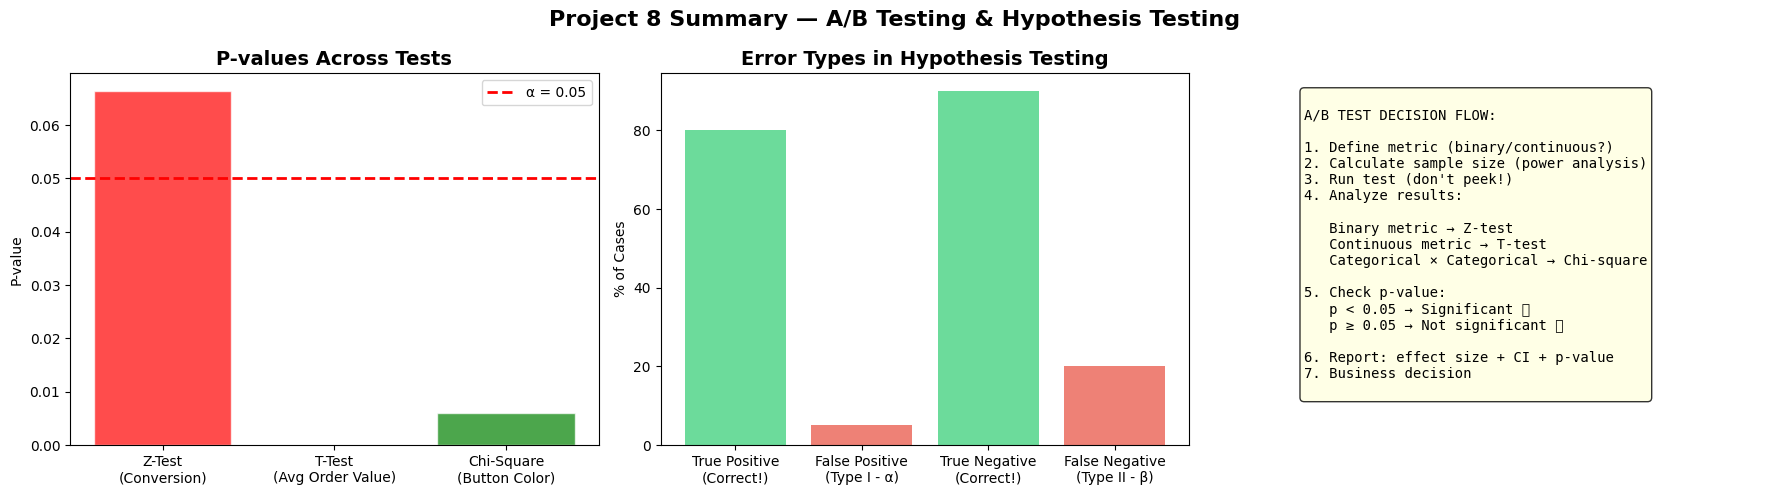


     PROJECT 8 COMPLETE — A/B TESTING & HYPOTHESIS TESTING

CONCEPTS COVERED:
  ✅ Hypothesis testing framework (H₀, H₁, p-value, α)
  ✅ Z-test for proportions (binary: conversion rates)
  ✅ T-test for means (continuous: order values, revenue)
  ✅ Chi-square test (categorical: button color × action)
  ✅ Confidence intervals (range of plausible effect sizes)
  ✅ Effect size — Cohen's d (practical significance)
  ✅ Power analysis (required sample size calculation)
  ✅ Multiple testing correction (Bonferroni)
  ✅ Common pitfalls (peeking, novelty, Simpson's paradox)
  ✅ Professional A/B test report format

CHARTS GENERATED:
  01 — Conversion rate comparison (bar chart)
  02 — Z-test visualization (normal curve with rejection regions)
  03 — T-test distributions (histograms + box plots)
  04 — Chi-square results (button color purchase rates)
  05 — Power curve (sample size vs detection probability)
  06 — Summary dashboard

KEY INTERVIEW TAKEAWAYS:
  • Binary metric → Z-test. Continuous me

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Summary of all three tests
tests = ['Z-Test\n(Conversion)', 'T-Test\n(Avg Order Value)', 'Chi-Square\n(Button Color)']
pvals = [p_value, t_pvalue, chi2_pvalue]
colors = ['green' if p < 0.05 else 'red' for p in pvals]

axes[0].bar(tests, pvals, color=colors, alpha=0.7, edgecolor='white')
axes[0].axhline(0.05, color='red', linewidth=2, linestyle='--', label='α = 0.05')
axes[0].set_title('P-values Across Tests', fontsize=14, fontweight='bold')
axes[0].set_ylabel('P-value')
axes[0].legend()

# Type I and II errors visualization
categories = ['True Positive\n(Correct!)', 'False Positive\n(Type I - α)', 
              'True Negative\n(Correct!)', 'False Negative\n(Type II - β)']
values = [80, 5, 90, 20]
colors2 = ['#2ecc71', '#e74c3c', '#2ecc71', '#e74c3c']
axes[1].bar(categories, values, color=colors2, alpha=0.7)
axes[1].set_title('Error Types in Hypothesis Testing', fontsize=14, fontweight='bold')
axes[1].set_ylabel('% of Cases')

# Decision flowchart as text
axes[2].axis('off')
flowchart = """
A/B TEST DECISION FLOW:

1. Define metric (binary/continuous?)
2. Calculate sample size (power analysis)
3. Run test (don't peek!)
4. Analyze results:
   
   Binary metric → Z-test
   Continuous metric → T-test
   Categorical × Categorical → Chi-square
   
5. Check p-value:
   p < 0.05 → Significant ✅
   p ≥ 0.05 → Not significant ❌
   
6. Report: effect size + CI + p-value
7. Business decision
"""
axes[2].text(0.1, 0.95, flowchart, transform=axes[2].transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Project 8 Summary — A/B Testing & Hypothesis Testing', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('06_summary.png', dpi=150, bbox_inches='tight')
plt.show()


print("\n" + "=" * 70)
print("     PROJECT 8 COMPLETE — A/B TESTING & HYPOTHESIS TESTING")
print("=" * 70)
print("""
CONCEPTS COVERED:
  ✅ Hypothesis testing framework (H₀, H₁, p-value, α)
  ✅ Z-test for proportions (binary: conversion rates)
  ✅ T-test for means (continuous: order values, revenue)
  ✅ Chi-square test (categorical: button color × action)
  ✅ Confidence intervals (range of plausible effect sizes)
  ✅ Effect size — Cohen's d (practical significance)
  ✅ Power analysis (required sample size calculation)
  ✅ Multiple testing correction (Bonferroni)
  ✅ Common pitfalls (peeking, novelty, Simpson's paradox)
  ✅ Professional A/B test report format

CHARTS GENERATED:
  01 — Conversion rate comparison (bar chart)
  02 — Z-test visualization (normal curve with rejection regions)
  03 — T-test distributions (histograms + box plots)
  04 — Chi-square results (button color purchase rates)
  05 — Power curve (sample size vs detection probability)
  06 — Summary dashboard

KEY INTERVIEW TAKEAWAYS:
  • Binary metric → Z-test. Continuous metric → T-test. Cat × Cat → Chi-square.
  • p-value < 0.05 → reject H₀ (difference is real)
  • Statistical significance ≠ practical significance (always report effect size)
  • Calculate sample size BEFORE running the test (power analysis)
  • Don't peek at results early (inflates false positive rate)
  • Bonferroni correction when testing multiple metrics: α/n
  • Always report: p-value + confidence interval + effect size
""")
print("=" * 70)